# 02 – Feature Engineering

**Project:** Area Feasibility Scoring Model  
**Goal:** Build a leakage-safe feature engineering pipeline and validate that each feature adds signal.

---
### Contents
1. Setup
2. Train/Test Split (before any feature computation)
3. Feature Engineering with `LeakageSafeFeaturizer`
4. Leakage Audit
5. Feature Distributions
6. Correlation with Target
7. Feature Summary

## 1 · Setup

In [15]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

from data_loader import prepare_dataset
from features import (
    LeakageSafeFeaturizer,
    FEATURE_COLS,
    CLASSIFICATION_TARGET,
    assert_no_leakage,
    build_target,
)

RANDOM_STATE = 42
USER_BUDGET  = 500_000

In [16]:
# Load area-level data (synthetic for demonstration)
area_df = prepare_dataset(user_budget=USER_BUDGET, use_synthetic=False, path = '../data/pp-complete.csv')

# Build classification target BEFORE splitting (it's just a column comparison, no stats)
y = build_target(area_df)

print(f'Areas: {len(area_df)}')
print(f'Target distribution:\n{y.value_counts().rename({0: "Not Affordable", 1: "Affordable"})}')

Loading data from: ../data/pp-complete.csv
Dataset prepared: 2307 areas, user budget £500,000
Areas: 2307
Target distribution:
affordable
Affordable        2008
Not Affordable     299
Name: count, dtype: int64


## 2 · Train/Test Split (BEFORE feature computation)

> **Key leakage principle:** We split the data *before* fitting the featurizer.  
> The `LeakageSafeFeaturizer` is then `fit` **only on training rows** and
> `transform`ed on both train and test independently.

In [17]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    area_df, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f'Train: {len(X_train_raw)} rows  |  Test: {len(X_test_raw)} rows')
print(f'Train affordability rate : {y_train.mean():.1%}')
print(f'Test  affordability rate : {y_test.mean():.1%}')

Train: 1845 rows  |  Test: 462 rows
Train affordability rate : 87.0%
Test  affordability rate : 87.0%


## 3 · Feature Engineering with `LeakageSafeFeaturizer`

In [18]:
featurizer = LeakageSafeFeaturizer(add_interactions=True)

# fit on TRAINING DATA ONLY
featurizer.fit(X_train_raw)

# transform both splits independently
X_train = featurizer.transform(X_train_raw)
X_test  = featurizer.transform(X_test_raw)

print('Training features shape:', X_train.shape)
print('Test features shape    :', X_test.shape)
X_train.head()

Training features shape: (1845, 11)
Test features shape    : (462, 11)


,affordability_ratio,budget_vs_p25,budget_vs_p75,price_spread,price_spread_pct,pct_within_budget,budget_deficit,log_budget,log_median_price,log_num_listings,ratio_x_spread
1309,2.272727,2.936858,1.694915,124750.0,0.567045,0.953914,-280000.0,13.122365,12.301387,7.266129,1.288740
2269,3.215434,4.694836,2.380952,103500.0,0.665595,0.988942,-344500.0,13.122365,11.954407,5.802118,2.140176
2177,3.184713,4.595187,2.132196,125690.5,0.800576,0.975495,-343000.0,13.122365,11.964007,7.377759,2.549606
2152,0.105263,0.221239,0.023810,18740000.0,3.945263,0.424052,4250000.0,13.122365,15.373655,3.912023,0.415291
1357,2.325581,3.225806,1.870907,112250.0,0.522093,0.968557,-285000.0,13.122365,12.278398,6.923629,1.214170


In [19]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
affordability_ratio,1845.0,1.873542,9.593930e-01,0.011161,1.219512,1.724138,2.325581,1.000000e+01
budget_vs_p25,1845.0,2.547294,1.365869e+00,0.011161,1.648805,2.242152,3.125000,1.388889e+01
budget_vs_p75,1845.0,1.372282,6.864645e-01,0.011161,0.907029,1.265983,1.740644,5.814021e+00
price_spread,1845.0,329687.023984,1.263091e+06,0.000000,122500.000000,167000.000000,253751.000000,2.996375e+07
price_spread_pct,1845.0,0.670023,4.832639e-01,0.000000,0.515244,0.613372,0.722222,1.005781e+01
pct_within_budget,1832.0,0.777408,2.014062e-01,0.008589,0.623482,0.841611,0.954899,1.000000e+00
budget_deficit,1845.0,-66973.431978,1.436891e+06,-450000.000000,-285000.000000,-210000.000000,-90000.000000,4.430000e+07
log_budget,1845.0,13.122365,1.776838e-15,13.122365,13.122365,13.122365,13.122365,1.312237e+01
log_median_price,1845.0,12.630986,5.827719e-01,10.819798,12.278398,12.577640,12.923915,1.761772e+01
log_num_listings,1845.0,6.216695,1.130813e+00,0.693147,5.886104,6.519147,6.909753,8.178077e+00


## 4 · Leakage Audit

In [20]:
# Confirm no feature is also a target column
assert_no_leakage(FEATURE_COLS, [CLASSIFICATION_TARGET, 'median_price'])

# Confirm raw price columns are NOT in the engineered feature set
raw_price_cols = {'median_price', 'price_25th', 'price_75th', 'budget'}
leaky = raw_price_cols & set(X_train.columns)
if leaky:
    print(f'WARNING: raw price columns found in features: {leaky}')
else:
    print('✓ Raw price columns correctly excluded from feature matrix.')
    print('✓ Feature matrix columns:', list(X_train.columns))

✓ Raw price columns correctly excluded from feature matrix.
✓ Feature matrix columns: ['affordability_ratio', 'budget_vs_p25', 'budget_vs_p75', 'price_spread', 'price_spread_pct', 'pct_within_budget', 'budget_deficit', 'log_budget', 'log_median_price', 'log_num_listings', 'ratio_x_spread']


## 5 · Feature Distributions

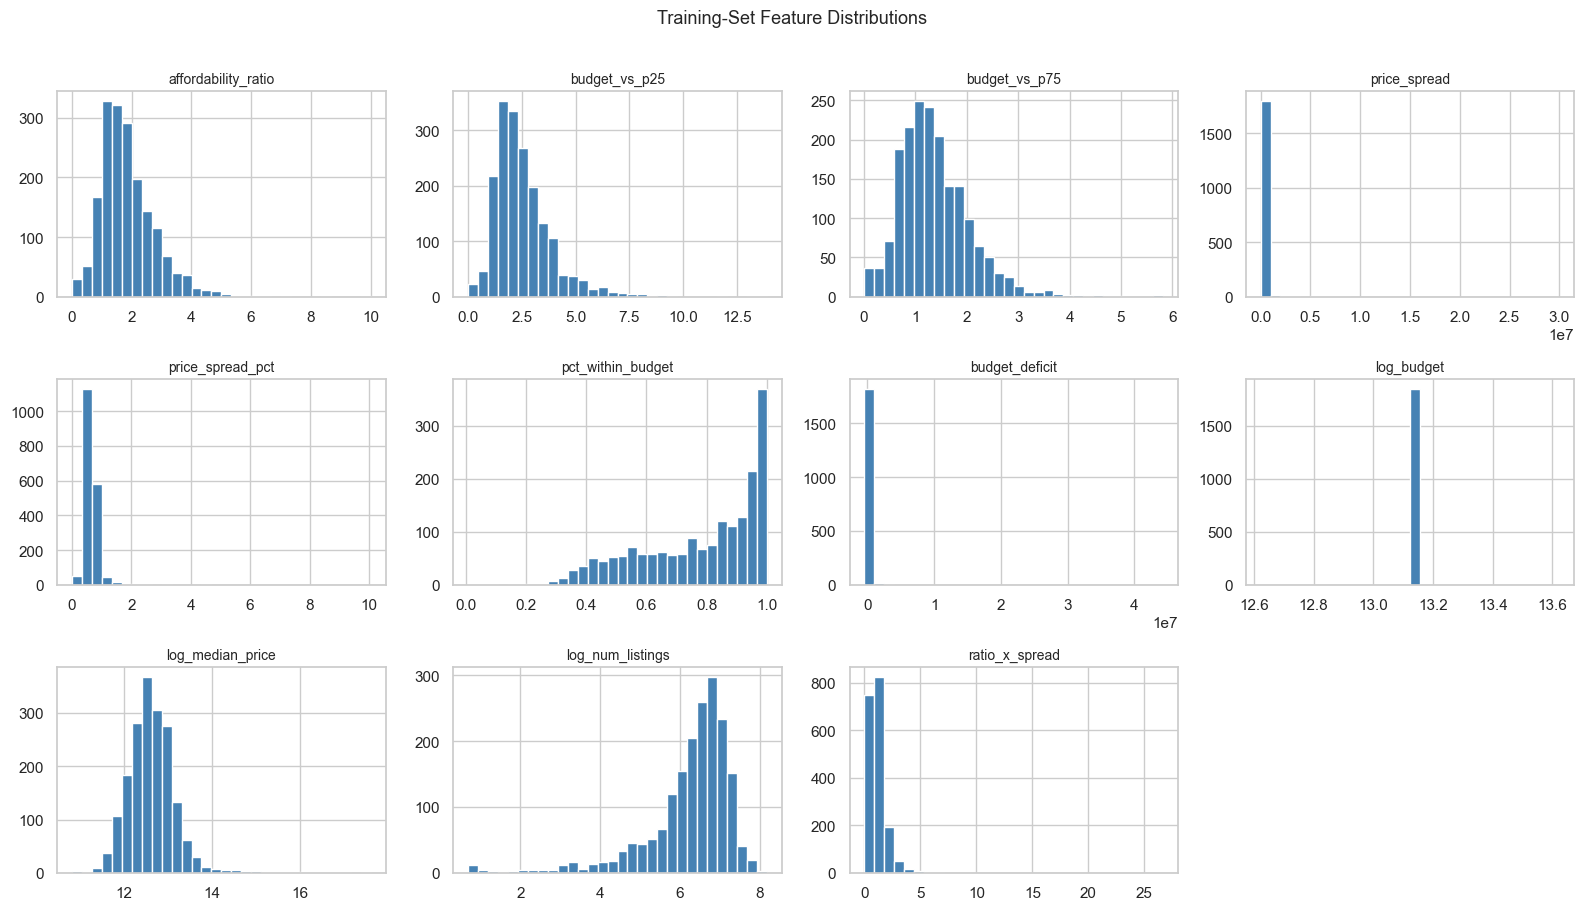

In [21]:
n_cols = 4
n_rows = int(np.ceil(len(FEATURE_COLS) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    axes[i].hist(X_train[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

# Hide unused subplot slots
for j in range(len(FEATURE_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Training-Set Feature Distributions', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 6 · Correlation with Target

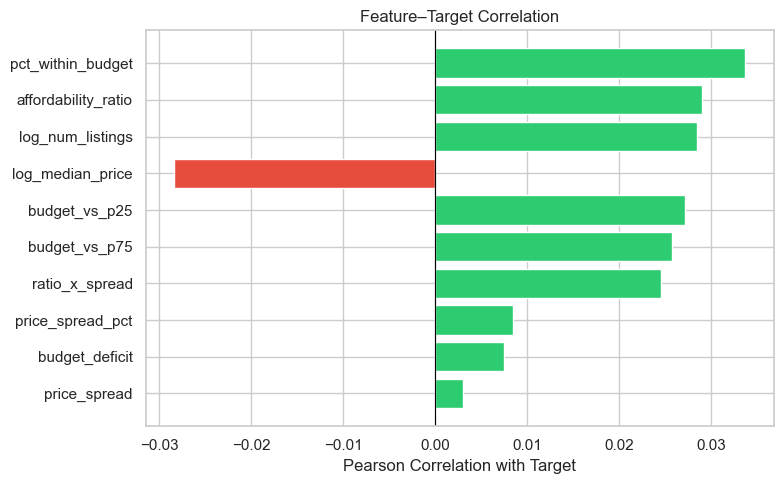

pct_within_budget      0.033715
affordability_ratio    0.028984
log_num_listings       0.028409
log_median_price      -0.028357
budget_vs_p25          0.027108
budget_vs_p75          0.025744
ratio_x_spread         0.024534
price_spread_pct       0.008411
budget_deficit         0.007465
price_spread           0.002965
log_budget                  NaN


In [22]:
# Point-biserial correlation between each feature and the binary target
correlations = (
    pd.concat([X_train, y_train.reset_index(drop=True)], axis=1)
    .corr()[CLASSIFICATION_TARGET]
    .drop(CLASSIFICATION_TARGET, errors='ignore')
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in correlations]
ax.barh(correlations.index[::-1], correlations.values[::-1], color=colors[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Target')
ax.set_title('Feature–Target Correlation')
plt.tight_layout()
plt.show()

print(correlations.to_string())

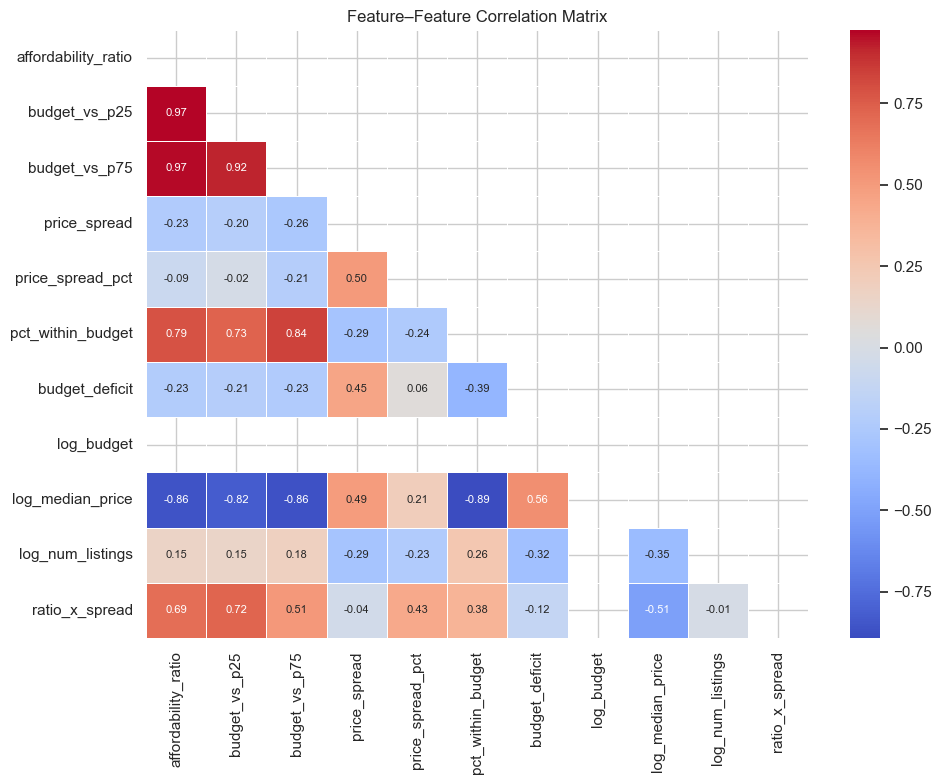

In [23]:
# Feature–feature correlation heatmap (check for multicollinearity)
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = X_train.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', linewidths=0.5, ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Feature–Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 7 · Feature Summary

| Feature | Description | Expected signal |
|---|---|---|
| `affordability_ratio` | budget / median_price | High correlation with target |
| `budget_vs_p25` | budget / 25th-pctile price | Affordability vs cheaper end |
| `budget_vs_p75` | budget / 75th-pctile price | Affordability vs expensive end |
| `price_spread` | IQR of area prices | Market volatility |
| `price_spread_pct` | IQR / median_price | Relative volatility |
| `pct_within_budget` | Estimated % listings ≤ budget | Supply signal |
| `budget_deficit` | median_price − budget | Signed gap |
| `log_budget` | log1p(budget) | Scale normalisation |
| `log_median_price` | log1p(median_price) | Scale normalisation |
| `log_num_listings` | log1p(num_listings) | Property supply |
| `ratio_x_spread` | ratio × spread_pct | Interaction term |

**Next step:** → `03_modeling.ipynb`